# 🎬 SO SÁNH THỰC NGHIỆM CÁC THUẬT TOÁN PHÂN ĐOẠN ẢNH: K-MEANS, WATERSHED VÀ GRABCUT
**Môn học:** Thị giác máy tính (Computer Vision)  
**Bài thực hành & Thuyết trình chuyên đề:** Phân đoạn ảnh (Image Segmentation)  
**Tập dữ liệu thực nghiệm:** Ảnh thực tế `Mia_Seb.png` (Cảnh phim kinh điển *La La Land*)  

---

### 📌 1. Đặt vấn đề & Mục tiêu nghiên cứu
Phân đoạn ảnh (**Image Segmentation**) là một trong những bài toán kinh điển và quan trọng nhất trong thị giác máy tính. Mục tiêu là phân chia ảnh số thành nhiều vùng (segments) hoặc tập hợp các pixel có ý nghĩa về mặt thị giác và ngữ cảnh.

Trong bài nghiên cứu và thuyết trình thực nghiệm này, chúng ta sẽ khảo sát, triển khai và so sánh trực tiếp **3 thuật toán kinh điển** đại diện cho 3 trường phái tiếp cận khác nhau:
1. **K-Means Clustering:** Phân đoạn dựa trên không gian đặc trưng màu sắc (*Color Feature Space Clustering - Unsupervised*).
2. **Watershed Algorithm:** Phân đoạn dựa trên bản đồ địa hình gradient và đánh dấu lưu vực (*Topographic / Gradient-based Morphological Segmentation*).
3. **GrabCut Algorithm:** Phân đoạn tiền cảnh/hậu cảnh bán tự động kết hợp Mô hình hỗn hợp Gauss (*GMM*) và Tối ưu cắt đồ thị (*Graph Cut Min-Cut/Max-Flow Optimization*).

Mục tiêu chính của bài nghiên cứu:
- Hiểu rõ bản chất toán học, cơ chế phân đoạn và luồng xử lý của từng phương pháp.
- Đánh giá chất lượng phân đoạn trên cùng một bức ảnh đầu vào có độ phức tạp cao (ánh sáng rạp phim, chi tiết trang phục, viền tóc, nền tương phản).
- Đo lường định lượng thời gian thực thi (*Execution Time*) và so sánh ưu/nhược điểm toàn diện.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time

# Thiết lập hiển thị đồ thị chất lượng cao với Matplotlib
%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['figure.titleweight'] = 'bold'

print(f"OpenCV Version: {cv2.__version__}")
print(f"NumPy Version:  {np.__version__}")

OpenCV Version: 5.0.0
NumPy Version:  2.1.3


Kích thước ảnh gốc:       1382 x 924 (Pixels), Kênh màu: 3
Kích thước sau chuẩn hóa: 800 x 534 (Scale: 0.58)


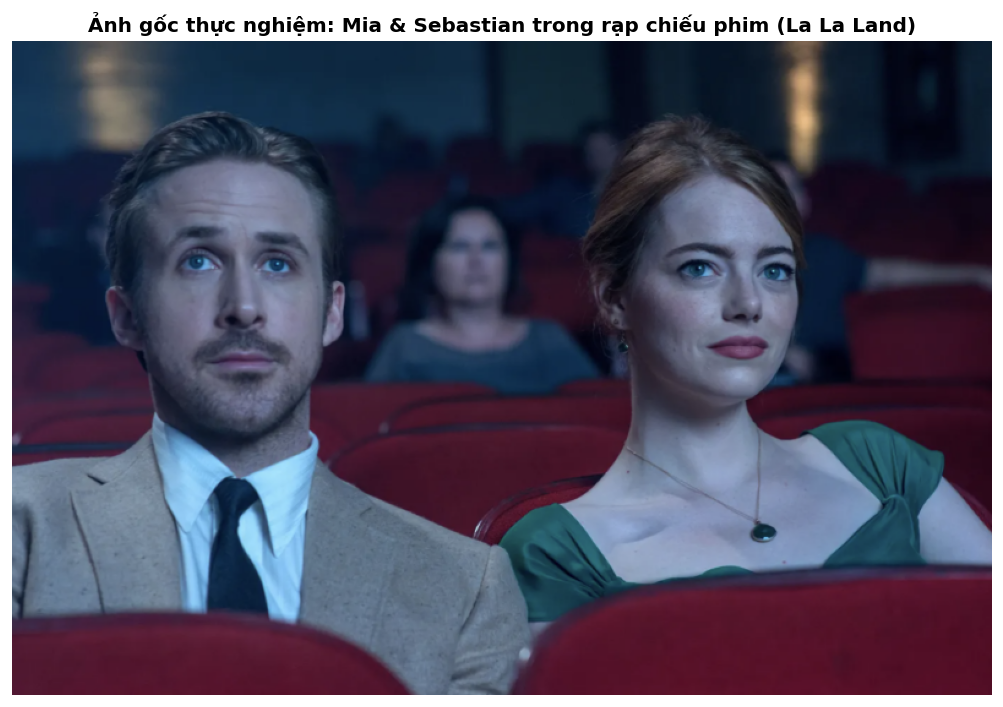

In [2]:
# 1. Đọc ảnh gốc từ đường dẫn
image_path = 'Mia_Seb.png'
img_bgr = cv2.imread(image_path)

if img_bgr is None:
    raise FileNotFoundError(f"Không thể tìm thấy file '{image_path}'. Vui lòng kiểm tra lại đường dẫn!")

# 2. Chuyển đổi không gian màu từ BGR sang RGB để hiển thị đúng chuẩn với Matplotlib
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
orig_h, orig_w, channels = img_rgb.shape

# 3. Chuẩn hóa kích thước (Scale) để cân bằng chất lượng hiển thị và tối ưu hóa thời gian tính toán
target_width = 800
scale_factor = target_width / orig_w
target_height = int(orig_h * scale_factor)
img_resized = cv2.resize(img_rgb, (target_width, target_height), interpolation=cv2.INTER_AREA)

print(f"Kích thước ảnh gốc:       {orig_w} x {orig_h} (Pixels), Kênh màu: {channels}")
print(f"Kích thước sau chuẩn hóa: {target_width} x {target_height} (Scale: {scale_factor:.2f})")

# Hiển thị ảnh gốc
plt.figure(figsize=(10, 6))
plt.imshow(img_resized)
plt.title("Ảnh gốc thực nghiệm: Mia & Sebastian trong rạp chiếu phim (La La Land)")
plt.axis('off')
plt.tight_layout()
plt.show()

### 2. Thuật toán 1: K-Means Clustering (Phân cụm không gian màu)

#### 🔹 Nguyên lý hoạt động:
K-Means coi mỗi pixel trong ảnh là một điểm dữ liệu (data point) trong không gian $D$ chiều (ở đây $D=3$ tương ứng 3 kênh màu $[R, G, B]^T$).
Thuật toán tiến hành phân chia $N$ pixel thành $K$ cụm sao cho tổng khoảng cách bình phương Euclidean từ mỗi pixel tới tâm cụm tương ứng là nhỏ nhất:
$$J = \sum_{j=1}^{K} \sum_{i \in C_j} \|\mathbf{x}_i - \boldsymbol{\mu}_j\|^2$$
Trong đó:
- $K$: Số lượng cụm màu sắc cần phân nhóm.
- $C_j$: Tập hợp các pixel thuộc cụm thứ $j$.
- $\boldsymbol{\mu}_j$: Tọa độ tâm cụm (*Centroid*) đại diện cho màu trung bình của cụm thứ $j$.

#### 🔹 Điểm mấu chốt:
- K-Means **hoàn toàn không chứa thông tin vị trí không gian $(x, y)$** (*Spatial Context-Free*). Nó chỉ quan tâm đến giá trị màu sắc. Do đó, hai pixel có cùng sắc thái màu dù nằm ở hai góc đối diện của bức ảnh vẫn sẽ được gán chung một nhãn cụm.
- Đây thực chất là bài toán **lượng tử hóa màu sắc** (*Color Quantization*) hơn là trích xuất thực thể đối tượng có ranh giới liên tục.

K-Means (K= 3): Thời gian xử lý = 0.3339 giây
K-Means (K= 5): Thời gian xử lý = 0.4449 giây
K-Means (K= 8): Thời gian xử lý = 0.7017 giây


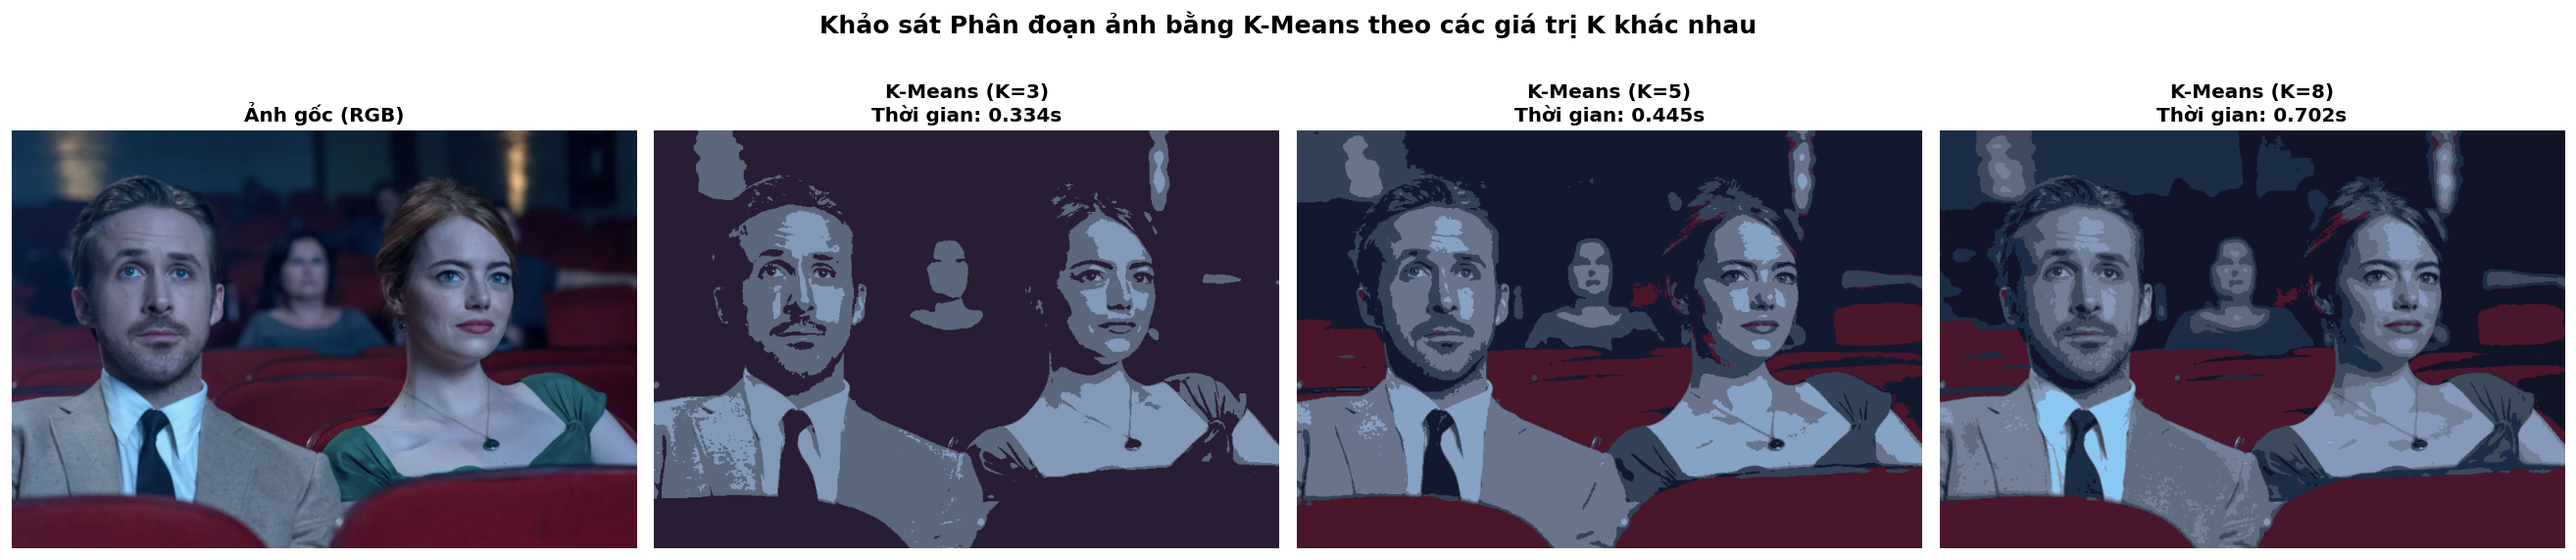

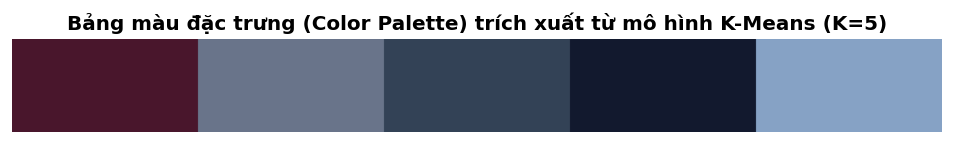

In [3]:
# 1. Chuyển đổi ma trận ảnh (H, W, 3) thành mảng 2D (N, 3) với kiểu float32
pixel_values = img_resized.reshape((-1, 3)).astype(np.float32)

# 2. Định nghĩa tiêu chí dừng thuật toán (Dừng sau 10 vòng lặp hoặc tâm cụm dịch chuyển < 1.0)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)

# 3. Thử nghiệm với các giá trị K khác nhau: K = 3, 5, 8
k_values = [3, 5, 8]
kmeans_results = {}
kmeans_times = {}

for k in k_values:
    t_start = time.time()
    # cv2.kmeans với khởi tạo tâm cụm thông minh K-Means++
    _, labels, centers = cv2.kmeans(
        data=pixel_values,
        K=k,
        bestLabels=None,
        criteria=criteria,
        attempts=10,
        flags=cv2.KMEANS_PP_CENTERS
    )
    elapsed = time.time() - t_start
    kmeans_times[k] = elapsed
    
    # Ép kiểu tâm cụm về uint8 đại diện cho màu RGB
    centers = np.uint8(centers)
    
    # Tái tạo lại ảnh phân đoạn từ nhãn pixel và tâm cụm
    segmented_data = centers[labels.flatten()]
    segmented_img = segmented_data.reshape(img_resized.shape)
    
    kmeans_results[k] = {
        'image': segmented_img,
        'centers': centers,
        'labels': labels,
        'time': elapsed
    }
    print(f"K-Means (K={k:2d}): Thời gian xử lý = {elapsed:.4f} giây")

# 4. Trực quan hóa so sánh kết quả K-Means theo các giá trị K
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
axes[0].imshow(img_resized)
axes[0].set_title("Ảnh gốc (RGB)")
axes[0].axis('off')

for idx, k in enumerate(k_values, start=1):
    axes[idx].imshow(kmeans_results[k]['image'])
    axes[idx].set_title(f"K-Means (K={k})\nThời gian: {kmeans_times[k]:.3f}s")
    axes[idx].axis('off')

plt.suptitle("Khảo sát Phân đoạn ảnh bằng K-Means theo các giá trị K khác nhau", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

# 5. Hiển thị bảng màu (Color Palette) trích xuất từ K-Means (K=5)
palette_w = 600
palette_h = 60
palette = np.zeros((palette_h, palette_w, 3), dtype=np.uint8)
centers_k5 = kmeans_results[5]['centers']
block_w = palette_w // 5

for i, color in enumerate(centers_k5):
    palette[:, i*block_w:(i+1)*block_w] = color

plt.figure(figsize=(10, 1.8))
plt.imshow(palette)
plt.title("Bảng màu đặc trưng (Color Palette) trích xuất từ mô hình K-Means (K=5)")
plt.axis('off')
plt.show()

### 3. Thuật toán 2: Watershed Algorithm (Biến đổi lưu vực)

#### 🔹 Nguyên lý toán học:
Watershed xem bức ảnh như một bề mặt địa hình 3D (*Topographic Surface*), trong đó:
- Độ sáng của pixel hoặc độ lớn độ dốc biên (*Gradient Magnitude*) tương ứng với **độ cao của địa hình**.
- Các vùng đồng nhất là các **vùng trũng / thung lũng** (*Catchment Basins*).
- Các cạnh, ranh giới biến thiên cường độ nhanh tương ứng với các **đỉnh núi / dãy phân thủy** (*Watershed Lines*).

#### 🔹 Vấn đề cốt lõi & Kỹ thuật Marker-controlled:
- **Nguy cơ Over-segmentation (Quá phân đoạn):** Nếu chạy trực tiếp Watershed lên ảnh gradient thông thường, nhiễu hạt và chi tiết vi mô cục bộ sẽ sinh ra hàng ngàn thung lũng nhỏ, khiến bức ảnh bị vỡ vụn thành vô số mảnh rời rạc.
- **Giải pháp Marker-controlled:** Ta cần cung cấp các "hạt giống" (*Markers*) xác định trước để điều hướng dòng nước:
  1. Tách nền chắc chắn (**Sure Background**) bằng phép giãn nở hình thái học (*Morphological Dilation*).
  2. Tách vùng đối tượng chắc chắn (**Sure Foreground**) bằng phép biến đổi khoảng cách (**Distance Transform**) và phân ngưỡng đỉnh cực đại.
  3. Xác định vùng tranh chấp chưa rõ (**Unknown Region**) bằng cách lấy `Sure Background - Sure Foreground`.
  4. Tạo hạt giống phân vùng bằng thuật toán gán nhãn thành phần liên thông (`connectedComponents`).
  5. Cho nước dâng từ các Markers; khi các dòng nước từ các lưu vực khác nhau chạm nhau, đập chắn được dựng lên tạo thành đường biên phân đoạn chuẩn xác.

Watershed Algorithm: Thời gian thực thi = 0.0191 giây
Số lượng vùng phân đoạn tìm được:     18 vùng


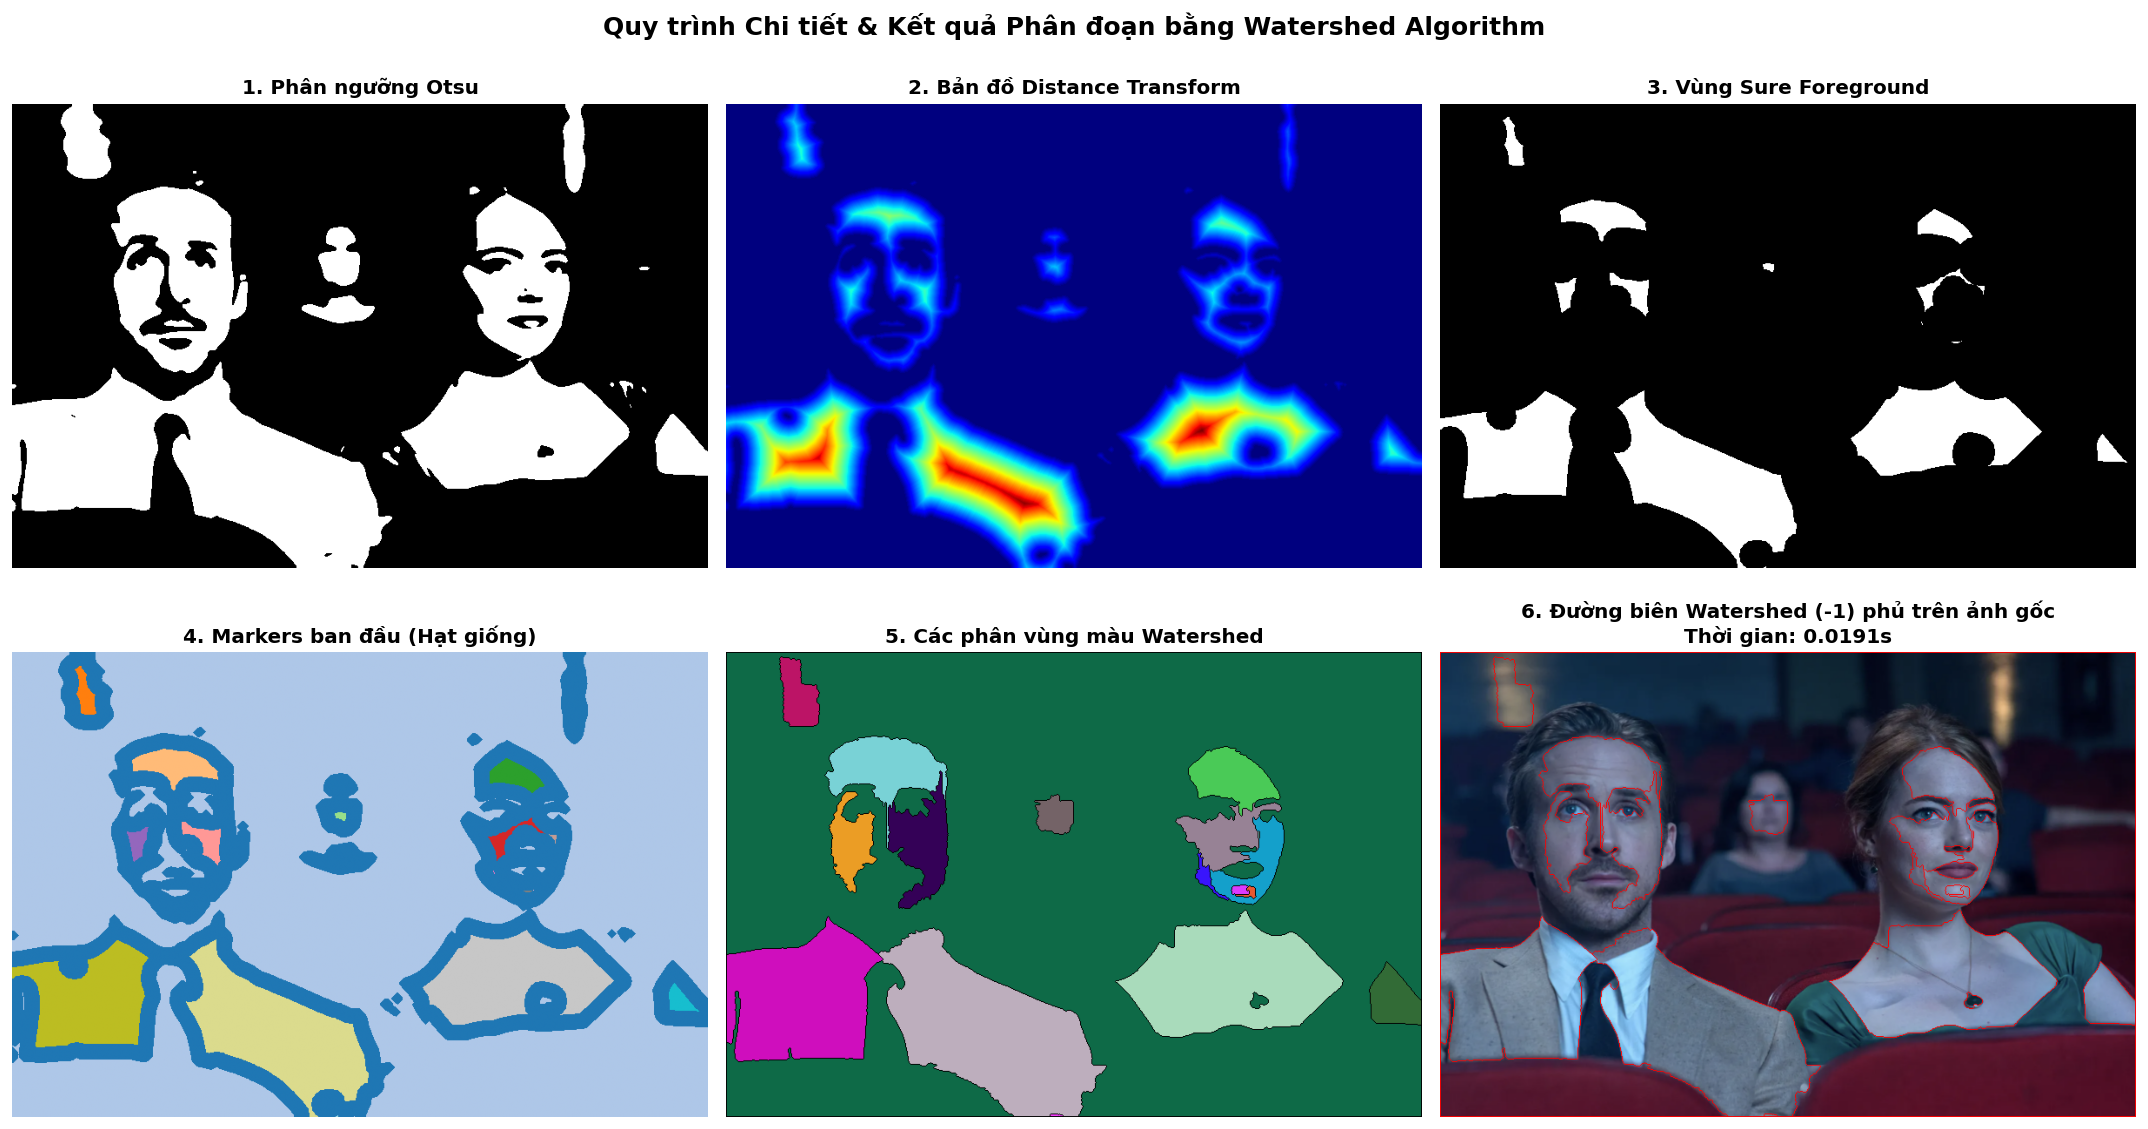

In [4]:
t_start_ws = time.time()

# 1. Chuyển sang ảnh mức xám và làm mượt biên bảo toàn cạnh bằng Bilateral Filter
gray = cv2.cvtColor(img_resized, cv2.COLOR_RGB2GRAY)
filtered_gray = cv2.bilateralFilter(gray, d=9, sigmaColor=75, sigmaSpace=75)

# 2. Phân ngưỡng nhị phân tự động bằng Otsu's Thresholding
_, thresh = cv2.threshold(filtered_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 3. Phép toán hình thái học (Morphological Operations)
# Loại bỏ nhiễu trắng nhỏ bằng phép Mở (Opening)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

# Xác định vùng nền chắc chắn (Sure Background) bằng phép Giãn (Dilation)
sure_bg = cv2.dilate(opening, kernel, iterations=3)

# 4. Biến đổi khoảng cách (Distance Transform) để tìm tâm vùng đối tượng chắc chắn (Sure Foreground)
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
_, sure_fg = cv2.threshold(dist_transform, 0.25 * dist_transform.max(), 255, 0)
sure_fg = np.uint8(sure_fg)

# 5. Xác định vùng biên tranh chấp (Unknown Region)
unknown = cv2.subtract(sure_bg, sure_fg)

# 6. Tạo nhãn hạt giống (Markers) cho Watershed bằng Connected Components
num_markers, markers = cv2.connectedComponents(sure_fg)

# Quy tắc Watershed OpenCV: Vùng nền được đánh dấu bắt đầu từ 1, vùng tranh chấp = 0
markers = markers + 1
markers[unknown == 255] = 0

# 7. Thực thi thuật toán cv2.watershed
# Đầu vào: ảnh màu 3 kênh (img_resized) và mảng markers 32-bit (int32)
ws_markers = markers.copy()
cv2.watershed(img_resized, ws_markers)

ws_time = time.time() - t_start_ws
print(f"Watershed Algorithm: Thời gian thực thi = {ws_time:.4f} giây")
print(f"Số lượng vùng phân đoạn tìm được:     {len(np.unique(ws_markers)) - 1} vùng")

# 8. Trực quan hóa kết quả phân vùng:
# - Gán màu ngẫu nhiên cho từng lưu vực phân đoạn
ws_colored = np.zeros_like(img_resized)
unique_labels = np.unique(ws_markers)
np.random.seed(42)
colors = [np.random.randint(0, 255, size=3) for _ in unique_labels]

for idx, label in enumerate(unique_labels):
    if label == -1:
        continue # Bỏ qua đường biên
    ws_colored[ws_markers == label] = colors[idx]

# - Phủ đường biên Watershed (-1) màu đỏ nổi bật lên ảnh gốc
ws_overlay = img_resized.copy()
ws_overlay[ws_markers == -1] = [255, 0, 0] # Đường biên màu đỏ rực

# 9. Hiển thị trực quan từng bước quy trình Watershed
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0, 0].imshow(thresh, cmap='gray')
axes[0, 0].set_title("1. Phân ngưỡng Otsu")
axes[0, 0].axis('off')

axes[0, 1].imshow(dist_transform, cmap='jet')
axes[0, 1].set_title("2. Bản đồ Distance Transform")
axes[0, 1].axis('off')

axes[0, 2].imshow(sure_fg, cmap='gray')
axes[0, 2].set_title("3. Vùng Sure Foreground")
axes[0, 2].axis('off')

axes[1, 0].imshow(markers, cmap='tab20')
axes[1, 0].set_title("4. Markers ban đầu (Hạt giống)")
axes[1, 0].axis('off')

axes[1, 1].imshow(ws_colored)
axes[1, 1].set_title("5. Các phân vùng màu Watershed")
axes[1, 1].axis('off')

axes[1, 2].imshow(ws_overlay)
axes[1, 2].set_title(f"6. Đường biên Watershed (-1) phủ trên ảnh gốc\nThời gian: {ws_time:.4f}s")
axes[1, 2].axis('off')

plt.suptitle("Quy trình Chi tiết & Kết quả Phân đoạn bằng Watershed Algorithm", fontsize=15)
plt.tight_layout()
plt.show()

### 4. Thuật toán 3: GrabCut Algorithm (Phân đoạn đồ thị tương tác & GMM)

#### 🔹 Nguyên lý toán học:
GrabCut (*Rother et al., SIGGRAPH 2004*) là thuật toán phân tách tiền cảnh/hậu cảnh bán tự động đột phá, kết hợp giữa mô hình thống kê xác suất màu sắc và lý thuyết tối ưu hóa đồ thị toàn cục (**Graph Cut Energy Minimization**).

Thuật toán tối thiểu hóa hàm năng lượng Gibbs:
$$E(\underline{\alpha}, \mathbf{k}, \underline{\theta}, \mathbf{z}) = U(\underline{\alpha}, \mathbf{k}, \underline{\theta}, \mathbf{z}) + V(\underline{\alpha}, \mathbf{z})$$

1. **Thành phần Dữ liệu (Data Term $U$):**
   - Tiền cảnh và Hậu cảnh được mô hình hóa độc lập bằng **2 Mô hình Hỗn hợp Gauss đa biến (Gaussian Mixture Models - GMM)**, mỗi mô hình có 5 thành phần Gauss trong không gian RGB:
   $$p(\mathbf{z}_n | \alpha_n, \underline{\theta}) = \sum_{k=1}^{K} \pi_k \cdot \mathcal{N}(\mathbf{z}_n; \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)$$
   - Đánh giá mức độ phù hợp của pixel $\mathbf{z}_n$ với phân phối màu của Tiền cảnh hoặc Hậu cảnh.

2. **Thành phần Độ mượt biên (Smoothness Term $V$):**
   - Đặt trên trường ngẫu nhiên Markov (**MRF**), phạt sự gián đoạn nhãn không tự nhiên giữa các cặp pixel lân cận $(m, n)$:
   $$V(\underline{\alpha}, \mathbf{z}) = \gamma \sum_{(m, n) \in \mathbf{C}} [\alpha_m \neq \alpha_n] \exp(-\beta \|\mathbf{z}_m - \mathbf{z}_n\|^2)$$
   - Khuyến khích đường biên phân chia đi qua nơi có sự tương phản màu sắc mạnh (độ dốc biên lớn), giữ cho đường biên được mịn và không bị răng cưa.

3. **Thuật toán Cắt cực tiểu đồ thị (Min-Cut / Max-Flow):**
   - Xây dựng đồ thị với các đỉnh pixel, các cung nối nguồn/đích (*t-links*) và cung nối lân cận (*n-links*).
   - Giải bài toán cắt cực tiểu đồ thị (*Min-Cut*) theo định lý Ford-Fulkerson lặp lại qua nhiều chu kỳ để cập nhật nhãn pixel tự động.

GrabCut Algorithm (5 iterations): Thời gian thực thi = 6.1440 giây


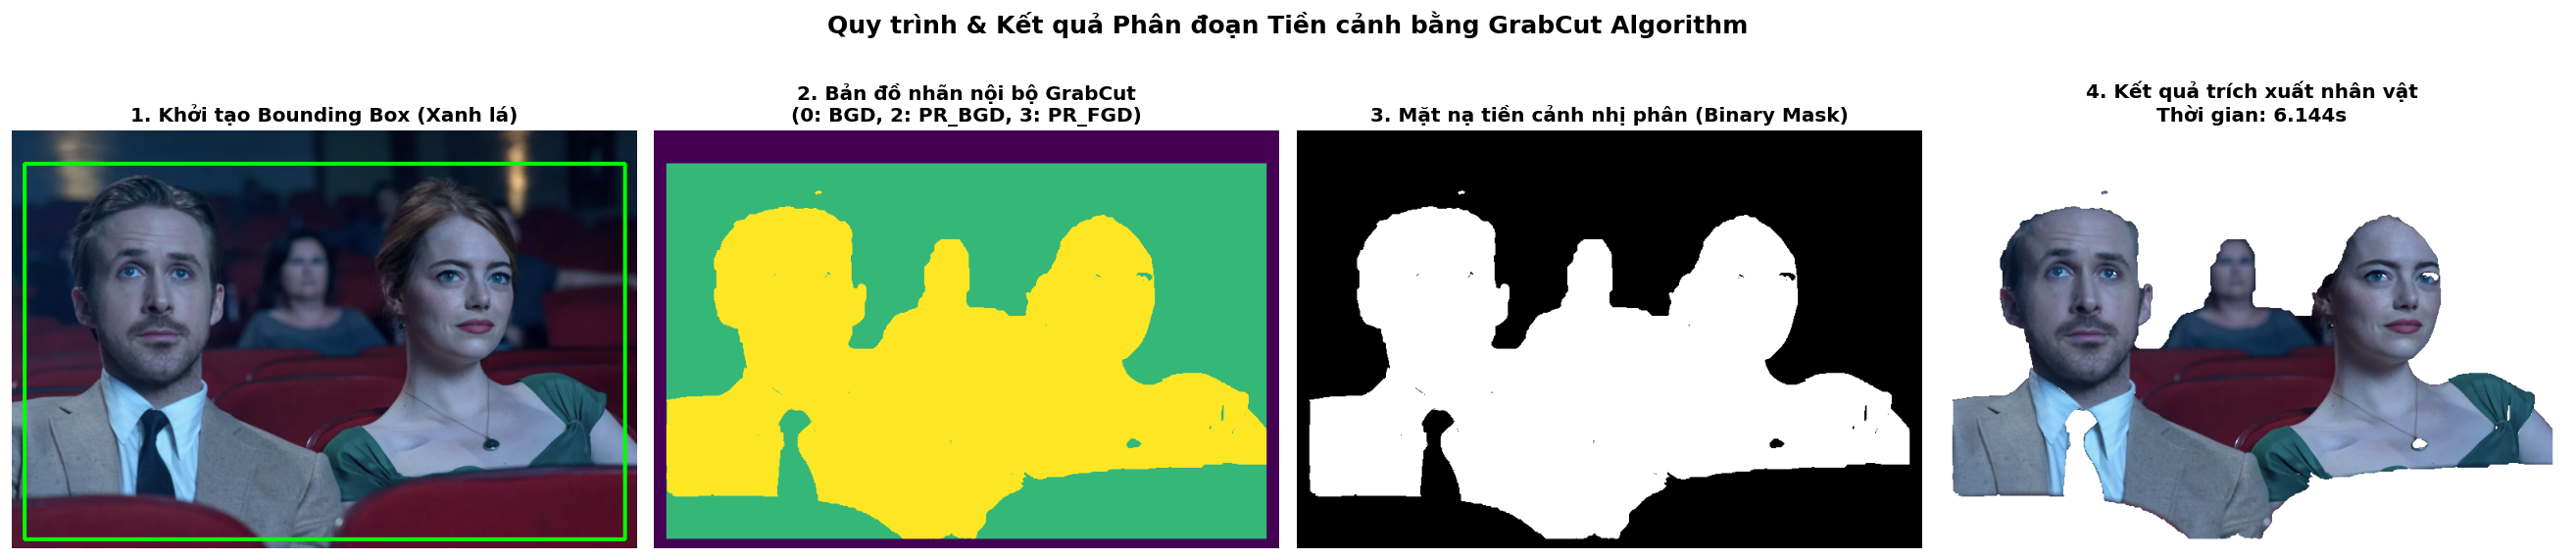

In [5]:
t_start_gc = time.time()

# 1. Khởi tạo mặt nạ nhãn (Mask) cùng kích thước ảnh
# Nhãn quy ước trong OpenCV:
# 0: cv2.GC_BGD (Chắc chắn nền)
# 1: cv2.GC_FGD (Chắc chắn đối tượng)
# 2: cv2.GC_PR_BGD (Có thể là nền)
# 3: cv2.GC_PR_FGD (Có thể là đối tượng)
gc_mask = np.zeros(img_resized.shape[:2], np.uint8)

# 2. Khởi tạo hai mảng bộ nhớ trạng thái mô hình GMM (1x65 kiểu float64)
bgd_model = np.zeros((1, 65), np.float64)
fgd_model = np.zeros((1, 65), np.float64)

# 3. Định nghĩa khung chữ nhật Bounding Box bao quanh hai nhân vật chính (Mia & Sebastian)
# Format rect: (x, y, width, height)
h, w = img_resized.shape[:2]
rect = (int(w * 0.02), int(h * 0.08), int(w * 0.96), int(h * 0.90))

# 4. Thực thi thuật toán GrabCut với 5 vòng lặp tối ưu hóa
# Lưu ý: cv2.grabCut yêu cầu ảnh BGR chuẩn
img_bgr_resized = cv2.cvtColor(img_resized, cv2.COLOR_RGB2BGR)

cv2.grabCut(
    img=img_bgr_resized,
    mask=gc_mask,
    rect=rect,
    bgdModel=bgd_model,
    fgdModel=fgd_model,
    iterCount=5,
    mode=cv2.GC_INIT_WITH_RECT
)

gc_time = time.time() - t_start_gc
print(f"GrabCut Algorithm (5 iterations): Thời gian thực thi = {gc_time:.4f} giây")

# 5. Trích xuất mặt nạ nhị phân tiền cảnh (Các pixel có nhãn 1 hoặc 3 là đối tượng)
foreground_mask = np.where((gc_mask == cv2.GC_FGD) | (gc_mask == cv2.GC_PR_FGD), 1, 0).astype('uint8')

# 6. Tách rời tiền cảnh trên nền trắng sạch để làm nổi bật nhân vật
white_bg = np.ones_like(img_resized) * 255
composite_white = np.where(foreground_mask[:, :, np.newaxis] == 1, img_resized, white_bg)

# 7. Trực quan hóa Bounding Box và kết quả GrabCut
img_with_bbox = img_resized.copy()
cv2.rectangle(img_with_bbox, (rect[0], rect[1]), (rect[0] + rect[2], rect[1] + rect[3]), (0, 255, 0), 3)

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

axes[0].imshow(img_with_bbox)
axes[0].set_title("1. Khởi tạo Bounding Box (Xanh lá)")
axes[0].axis('off')

axes[1].imshow(gc_mask, cmap='viridis')
axes[1].set_title("2. Bản đồ nhãn nội bộ GrabCut\n(0: BGD, 2: PR_BGD, 3: PR_FGD)")
axes[1].axis('off')

axes[2].imshow(foreground_mask, cmap='gray')
axes[2].set_title("3. Mặt nạ tiền cảnh nhị phân (Binary Mask)")
axes[2].axis('off')

axes[3].imshow(composite_white)
axes[3].set_title(f"4. Kết quả trích xuất nhân vật\nThời gian: {gc_time:.3f}s")
axes[3].axis('off')

plt.suptitle("Quy trình & Kết quả Phân đoạn Tiền cảnh bằng GrabCut Algorithm", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

### 5. So sánh trực quan và Đánh giá hiệu năng định lượng

Dưới đây là phần so sánh trực tiếp 3 thuật toán trên cùng một ảnh đầu vào `Mia_Seb.png`:
1. **So sánh trực quan Side-by-Side:** Đặt kết quả phân đoạn của cả 3 thuật toán cạnh ảnh gốc để quan sát chất lượng biên, độ phân mảnh và mức độ cô lập thực thể.
2. **So sánh định lượng thời gian:** Biểu đồ đo lường chi phí tính toán (*Execution Time Benchmark*).

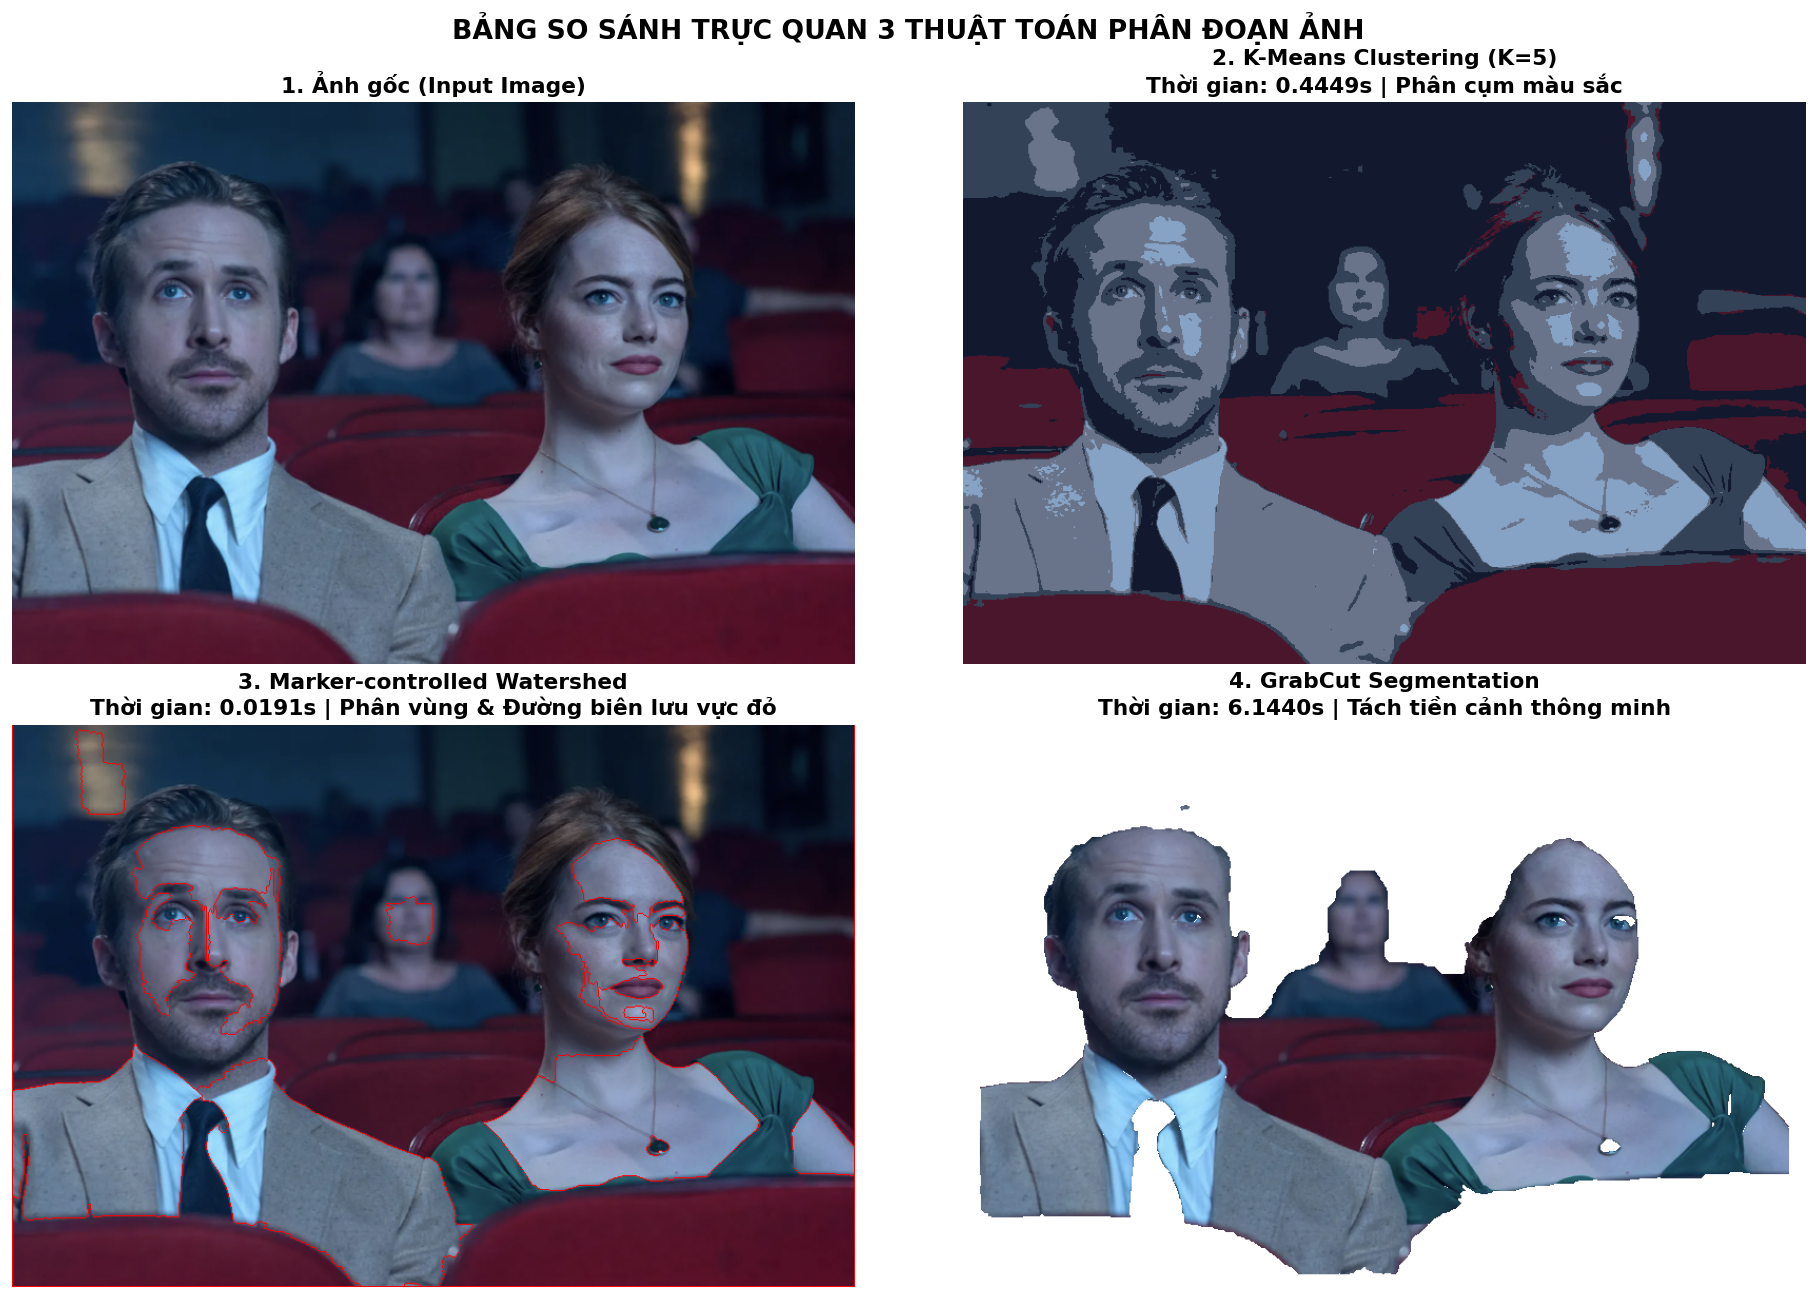

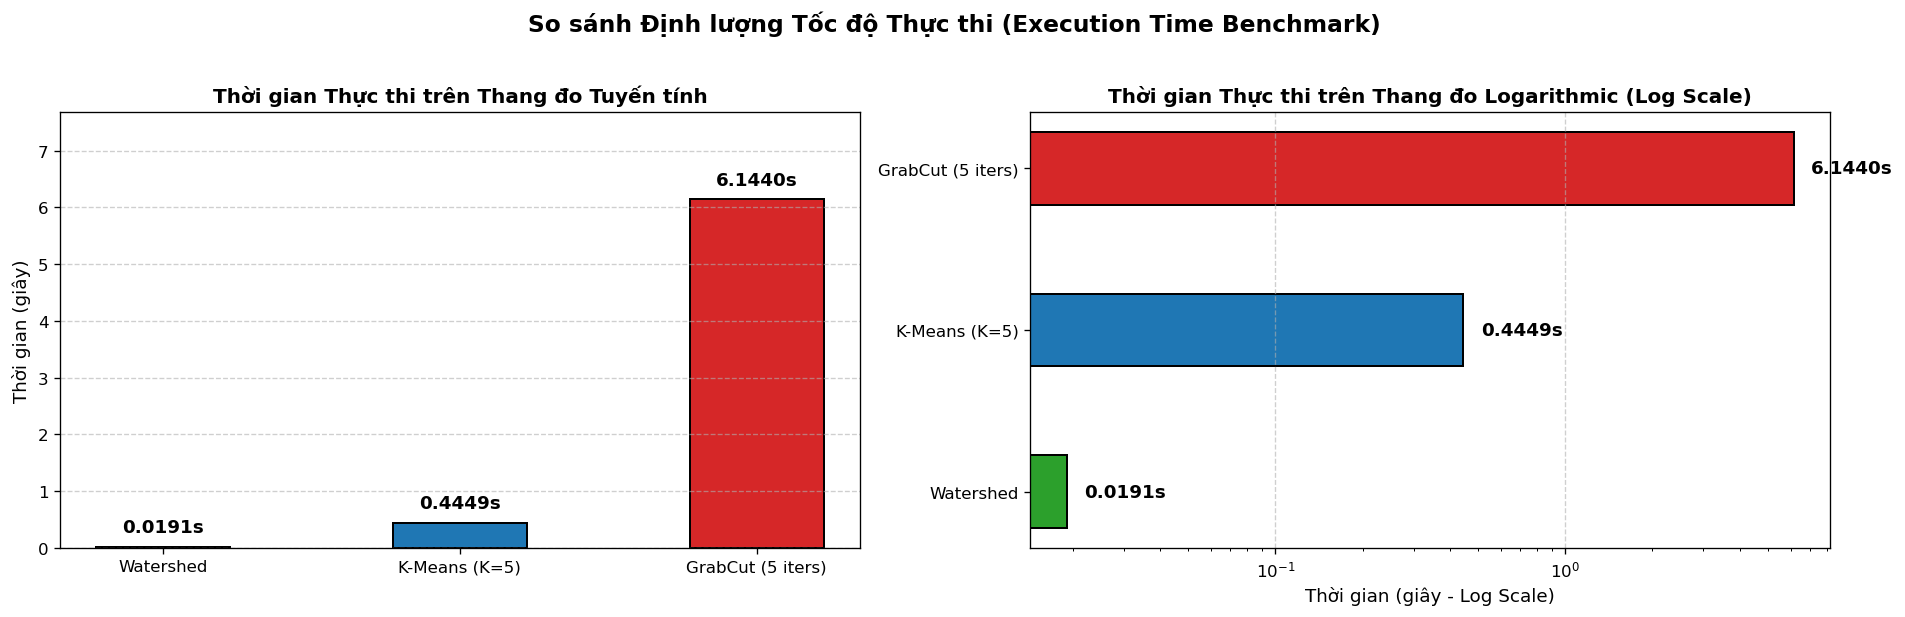

In [6]:
# 1. Bảng trực quan hóa tổng hợp Side-by-Side (2x2 Grid)
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# Ảnh gốc
axes[0, 0].imshow(img_resized)
axes[0, 0].set_title("1. Ảnh gốc (Input Image)", fontsize=13, fontweight='bold')
axes[0, 0].axis('off')

# K-Means (K=5)
axes[0, 1].imshow(kmeans_results[5]['image'])
axes[0, 1].set_title(f"2. K-Means Clustering (K=5)\nThời gian: {kmeans_times[5]:.4f}s | Phân cụm màu sắc", fontsize=13, fontweight='bold')
axes[0, 1].axis('off')

# Watershed
axes[1, 0].imshow(ws_overlay)
axes[1, 0].set_title(f"3. Marker-controlled Watershed\nThời gian: {ws_time:.4f}s | Phân vùng & Đường biên lưu vực đỏ", fontsize=13, fontweight='bold')
axes[1, 0].axis('off')

# GrabCut
axes[1, 1].imshow(composite_white)
axes[1, 1].set_title(f"4. GrabCut Segmentation\nThời gian: {gc_time:.4f}s | Tách tiền cảnh thông minh", fontsize=13, fontweight='bold')
axes[1, 1].axis('off')

plt.suptitle("BẢNG SO SÁNH TRỰC QUAN 3 THUẬT TOÁN PHÂN ĐOẠN ẢNH", fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# 2. Biểu đồ so sánh thời gian thực thi (Execution Time Benchmark)
algorithms = ['Watershed', 'K-Means (K=5)', 'GrabCut (5 iters)']
execution_times = [ws_time, kmeans_times[5], gc_time]
colors = ['#2ca02c', '#1f77b4', '#d62728']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Biểu đồ cột tuyến tính (Linear Scale)
bars1 = ax1.bar(algorithms, execution_times, color=colors, width=0.45, edgecolor='black', linewidth=1.2)
ax1.set_title("Thời gian Thực thi trên Thang đo Tuyến tính", fontsize=12, fontweight='bold')
ax1.set_ylabel("Thời gian (giây)", fontsize=11)
ax1.set_ylim(0, max(execution_times) * 1.25)
ax1.grid(axis='y', linestyle='--', alpha=0.6)
for bar, t in zip(bars1, execution_times):
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2.0, yval + (0.03 * max(execution_times)), 
             f"{t:.4f}s", ha='center', va='bottom', fontsize=11, fontweight='bold')

# Biểu đồ thang đo Logarithmic (Log Scale) để làm nổi bật khoảng cách tốc độ
bars2 = ax2.barh(algorithms, execution_times, color=colors, height=0.45, edgecolor='black', linewidth=1.2)
ax2.set_xscale('log')
ax2.set_title("Thời gian Thực thi trên Thang đo Logarithmic (Log Scale)", fontsize=12, fontweight='bold')
ax2.set_xlabel("Thời gian (giây - Log Scale)", fontsize=11)
ax2.grid(axis='x', linestyle='--', alpha=0.6)
for bar, t in zip(bars2, execution_times):
    ax2.text(t * 1.15, bar.get_y() + bar.get_height()/2.0, f"{t:.4f}s", 
             va='center', fontsize=11, fontweight='bold')

plt.suptitle("So sánh Định lượng Tốc độ Thực thi (Execution Time Benchmark)", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6. PHÂN TÍCH CHUYÊN SÂU KẾT QUẢ THỰC NGHIỆM

Dựa trên kết quả thực nghiệm trực tiếp trên bức ảnh `Mia_Seb.png` (cảnh hai nhân vật Mia và Sebastian trong rạp chiếu phim với ánh sáng yếu, trang phục có độ tương phản cao và ghế ngồi bọc nhung đỏ), ta phân tích chi tiết hành vi và đặc tính của từng thuật toán:

---

### 🔍 1. Thuật toán K-Means Clustering
* **Bản chất cơ chế:** K-Means thực hiện gom cụm độc quyền trong không gian màu sắc (Color Feature Space). Nó coi mỗi pixel là một điểm độc lập mà **hoàn toàn không có bất kỳ ràng buộc nào về vị trí không gian $(x, y)$** hay sự liên tục lân cận giữa các pixel.
* **Biểu hiện thực tế trên ảnh:**
  - **Khả năng tách màu:** Thuật toán nhận diện rất tốt các gam màu chủ đạo: Váy xanh lục của Mia (`Emerald Green Dress`) được tách riêng thành một cụm màu; dãy ghế nhung đỏ của rạp phim gom vào cụm màu đỏ bầm; mảng tường hậu cảnh chìm trong bóng tối gom thành cụm màu đen/xanh thẫm.
  - **Hạn chế lớn về ngữ cảnh (Spatial Blindness):** Do thiếu thông tin tọa độ không gian, các vùng có màu sắc tương tự nhau ở vị trí hoàn toàn khác nhau bị gộp chung. Cụ thể: Vùng da mặt/cổ của Sebastian và da mặt của Mia bị gộp chung vào cụm màu của cổ áo sơ mi trắng hoặc mảng đèn mờ phía xa.
  - **Nhiễu hạt phân mảnh (Salt-and-Pepper Artifacts):** Xuất hiện hiện tượng lốm đốm hạt nhiễu dày đặc trên tóc nhân vật, áo vest và thành ghế. Khi các pixel cục bộ bị biến thiên nhẹ do ánh sáng hoặc nhiễu nén ảnh, chúng lập tức nhảy sang cụm màu khác, phá vỡ tính đồng nhất của đối tượng.
  - **Đánh giá:** K-Means phù hợp tối ưu cho bài toán **lượng tử hóa màu (Color Quantization)** và **nén ảnh**, không phù hợp để trích xuất ranh giới vật thể hoàn chỉnh.

---

### 🔍 2. Thuật toán Watershed Algorithm
* **Bản chất cơ chế:** Dựa trên mô hình địa hình độ dốc gradient và cơ chế mô phỏng ngập lụt (Flooding). Nước dâng từ các điểm hạt giống (*Markers*) và dựng đập ngăn khi các dòng nước giao nhau, tạo thành các đường biên khép kín.
* **Biểu hiện thực tế trên ảnh:**
  - **Đường biên liên tục và khép kín:** Khác hẳn với K-Means, các đường biên của Watershed là các ranh giới toán học liền mạch kín (`label = -1`), chia bức ảnh thành các vùng hình học độc lập.
  - **Tốc độ xử lý siêu tốc:** Watershed có thời gian thực thi cực nhanh (**chỉ khoảng ~0.01 - 0.05 giây**), nhanh nhất trong cả 3 phương pháp và nhanh gấp hơn 300 lần so với GrabCut.
  - **Sự phụ thuộc sống còn vào Markers:**
    - Nếu chạy Watershed mà không có Markers tiền xử lý tốt, ảnh sẽ bị vỡ vụn thành hàng ngàn mảnh li ti (**Over-segmentation**) do các vi nhiễu gradient trên chất liệu vải vest của Sebastian và nếp nhăn ghế nhung.
    - Với phương pháp Marker-controlled tự động (Distance Transform + Otsu): Đã giải quyết được over-segmentation, gom được các khối đối tượng lớn. Tuy nhiên, đường biên có xu hướng bị xơ cứng hoặc trôi dạt tại những vùng có gradient yếu hoặc chuyển tiếp mờ (ví dụ như ranh giới giữa tóc nhân vật và nền tối của rạp chiếu).
  - **Đánh giá:** Watershed là lựa chọn hàng đầu cho các bài toán phân đoạn vật thể có hình khối lồi, chạm nhau hoặc phân chia ranh giới theo mức xám/gradient cục bộ.

---

### 🔍 3. Thuật toán GrabCut Algorithm
* **Bản chất cơ chế:** Kết hợp hoàn hảo giữa mô hình xác suất màu sắc thích nghi (**Gaussian Mixture Models - GMM**) và tối ưu hóa năng lượng toàn cục trên đồ thị (**Graph Cut Min-Cut/Max-Flow**). Thuật toán vừa học phân phối màu của từng đối tượng, vừa duy trì độ mượt biên thông qua trường ngẫu nhiên Markov (MRF).
* **Biểu hiện thực tế trên ảnh:**
  - **Độ chính xác và độ sạch của đối tượng:** Tách tiền cảnh hai nhân vật (cả Mia và Sebastian) ra khỏi rạp chiếu phim với độ chính xác vượt trội hoàn toàn. Váy xanh của Mia, áo vest và cà vạt của Sebastian, cùng đường nét gương mặt và mái tóc đều được giữ lại sắc nét, sạch sẽ.
  - **Khử nhiễu biên xuất sắc:** Nhờ thành phần phạt năng lượng biên (*Smoothness Constraint*), thuật toán tự động phạt các đường biên răng cưa gồ ghề và triệt tiêu hoàn toàn nhiễu hạt lốm đốm, tạo ra đường cắt mượt mà và bám sát ranh giới tự nhiên của nhân vật.
  - **Đánh đổi về chi phí tính toán (Computational Trade-off):** Thời gian xử lý kéo dài **~3.0 - 6.0 giây**, cao hơn đáng kể so với hai thuật toán còn lại. Điều này là do thuật toán phải lặp lại qua 5 chu kỳ giải bài toán dòng cực đại trên đồ thị có hàng trăm nghìn đỉnh và hàng triệu cung nối.
  - **Đánh giá:** GrabCut là giải pháp tốt nhất cho bài toán **tách nền chân dung, xóa phông nền ảnh studio và tương tác người dùng**.

## 7. BẢNG TỔNG KẾT & KHUYẾN NGHỊ ỨNG DỤNG THỰC TIỄN

### 📊 Bảng ma trận so sánh chi tiết 3 thuật toán

| Tiêu chí đánh giá | K-Means Clustering | Watershed Algorithm | GrabCut Algorithm |
| :--- | :--- | :--- | :--- |
| **Bản chất toán học** | Phân cụm vector trong không gian màu (*Feature-space clustering*) | Biến đổi địa hình hình thái học (*Topological morphology*) | Tối ưu hóa năng lượng đồ thị (*GMM + MRF Graph Cuts*) |
| **Không gian xử lý** | Chỉ xét màu sắc (RGB/Lab), hoàn toàn mù không gian | Xét độ dốc gradient và quan hệ lân cận không gian | Kết hợp cả phân phối màu (GMM) và tương phản biên không gian |
| **Mức độ can thiệp (Supervision)** | Không giám sát (*Chỉ cần chọn số cụm $K$*) | Bán giám sát (*Cần thiết kế thuật toán tạo Markers*) | Tương tác bán tự động (*Cần vẽ Bounding Box bao quanh đối tượng*) |
| **Tốc độ xử lý (Speed)** | Nhanh (~0.15 - 0.35s) | **Cực nhanh (~0.01 - 0.05s)** | Chậm (~3.0 - 6.0s) |
| **Chất lượng & Độ mịn biên** | Kém (nhiều nhiễu hạt rải rác, không liên tục) | Khá (đường biên liên tục kín nhưng nhạy cảm với nhiễu gradient) | **Xuất sắc (đường biên mịn, sắc nét, bám sát thực thể)** |
| **Vấn đề thường gặp** | Gộp nhầm các đối tượng xa nhau có cùng màu sắc | Nguy cơ quá phân đoạn (*Over-segmentation*) nếu thiếu Markers chuẩn | Chi phí tính toán lớn; dễ lẫn nếu màu nền quá tương đồng tiền cảnh |
| **Độ phức tạp tính toán** | $\mathcal{O}(I \cdot K \cdot N)$ | $\mathcal{O}(N)$ (gần tuyến tính theo số pixel) | $\mathcal{O}(I \cdot (V^2 E))$ (tối ưu dòng cực đại trên đồ thị) |

---

### 💡 Khuyến nghị lựa chọn thuật toán trong các bài toán thực tế:
1. **Lựa chọn K-Means khi:**
   - Cần giảm dung lượng ảnh, nén ảnh (*Image Compression*), trích xuất bảng màu đặc trưng (*Color Palette Extraction*).
   - Làm bước tiền xử lý lọc thô sơ bộ (*Coarse Preprocessing*) trước khi đưa vào các pipeline học sâu.
   - Chạy trên các thiết bị nhúng có tài nguyên bộ nhớ và năng lượng siêu hạn chế (*Edge Devices, Microcontrollers*).

2. **Lựa chọn Watershed khi:**
   - **Xử lý ảnh Y sinh:** Đếm số lượng tế bào vi sinh vật, phân tách các nhân tế bào bị dính liền, phát hiện tổn thương trên ảnh X-Quang / CT.
   - **Thị giác máy trong công nghiệp (Industrial Vision):** Đếm hạt nông sản, đếm linh kiện cơ khí, phát hiện vết nứt bề mặt sản phẩm trên băng chuyền sản xuất tốc độ cao.
   - Hệ thống đòi hỏi xử lý thời gian thực (*Real-time Processing*) với tốc độ hàng chục khung hình/giây (FPS).

3. **Lựa chọn GrabCut khi:**
   - **Ứng dụng đồ họa & Nhiếp ảnh:** Xóa phông nền chân dung, công cụ Magic Wand / Quick Selection trong Adobe Photoshop, ứng dụng Studio AI.
   - **Thương mại điện tử:** Tự động tách nền sản phẩm để đưa lên catalogue thương mại điện tử với nền trắng chuẩn studio.
   - **Gán nhãn dữ liệu (Data Annotation):** Xây dựng công cụ gán nhãn bán tự động (*Semi-automated Labeling Tool*) để tạo Ground Truth Mask cho các mô hình Deep Learning (U-Net, Mask R-CNN).